### Procedure

For this quiz, you must build an end-to-end data analysis notebook following the ETL pipeline.

1. On a separate document, create a table with 3 columns. Column 1: Phase,  Column 2: Activity, and Column 3: Code and Output.
    * Phase will only have 3 major rows: Extract, Transform, Load
    * Activity will list down all the activities you performed per phase.
    * Code and output will correspond to the activity.

2. Extract the provided dataset using FLAT FILE. You get extra points for loading it through Kaggle API.

In [ ]:
! pip install kagglehub

In [48]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\tipqc\.cache\kagglehub\datasets\supplejade\rt-iot2022real-time-internet-of-things\versions\3


In [49]:
import pandas as pd
iot = pd.read_csv('RT_IOT2022.csv')

iot.head(5)

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


3. Transform the dataset. List down all activities included in the transformation.

In [50]:
iot.describe

<bound method NDFrame.describe of           no  id.orig_p  id.resp_p proto service  flow_duration  fwd_pkts_tot  \
0          0      38667       1883   tcp    mqtt      32.011598             9   
1          1      51143       1883   tcp    mqtt      31.883584             9   
2          2      44761       1883   tcp    mqtt      32.124053             9   
3          3      60893       1883   tcp    mqtt      31.961063             9   
4          4      51087       1883   tcp    mqtt      31.902362             9   
...      ...        ...        ...   ...     ...            ...           ...   
123112  2005      59247      63331   tcp       -       0.000006             1   
123113  2006      59247      64623   tcp       -       0.000007             1   
123114  2007      59247      64680   tcp       -       0.000006             1   
123115  2008      59247      65000   tcp       -       0.000006             1   
123116  2009      59247      65129   tcp       -       0.000006            

In [51]:
iot.dtypes


no                        int64
id.orig_p                 int64
id.resp_p                 int64
proto                    object
service                  object
                         ...   
idle.std                float64
fwd_init_window_size      int64
bwd_init_window_size      int64
fwd_last_window_size      int64
Attack_type              object
Length: 85, dtype: object

In [61]:
iot.isnull().sum()

no                      0
id.orig_p               0
id.resp_p               0
proto                   0
service                 0
                       ..
idle.std                0
fwd_init_window_size    0
bwd_init_window_size    0
fwd_last_window_size    0
Attack_type             0
Length: 85, dtype: int64

In [52]:
import seaborn as sns
fig = plt.figure(figsize=(20, 6))


<Figure size 2000x600 with 0 Axes>

4. Show the transformed dataset.

In [75]:
filtered_iot = iot.query("proto == 'icmp' and Attack_type == 'DOS_SYN_Hping'")
filtered_iot

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type


In [74]:
filtered_iot = iot.query("proto == 'udp' and Attack_type == 'DOS_SYN_Hping'")
filtered_iot

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type


In [84]:
filtered_iot = iot.query("proto == 'tcp' and Attack_type == 'DOS_SYN_Hping'")
filtered_iot

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
20791,0,2840,21,tcp,-,0.000041,1,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
20792,1,2841,21,tcp,-,0.000006,1,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
20793,2,2842,21,tcp,-,0.000005,1,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
20794,3,2843,21,tcp,-,0.000004,1,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
20795,4,2844,21,tcp,-,0.000004,1,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115445,94654,34865,21,tcp,-,0.000000,1,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
115446,94655,42729,21,tcp,-,0.000000,1,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
115447,94656,44682,21,tcp,-,0.000000,1,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping
115448,94657,41378,21,tcp,-,0.000000,1,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,64,0,64,DOS_SYN_Hping


5. Load the dataset and perform statistical analysis and visualization. List down all activities included in the "load" phase.

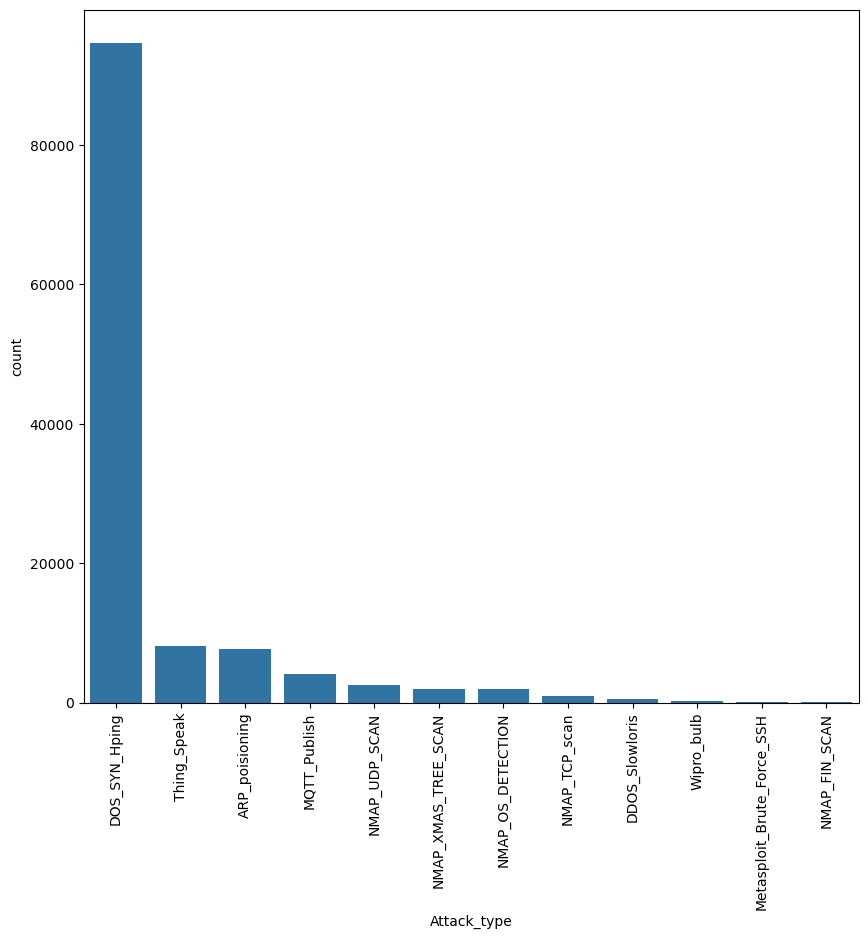

In [62]:
import seaborn as sns
figure = plt.subplots(figsize=(10,9))
sns.countplot(data=iot,x=iot['Attack_type'],order=iot['Attack_type'].value_counts().index)
plt.xticks(rotation=90)
plt.show()

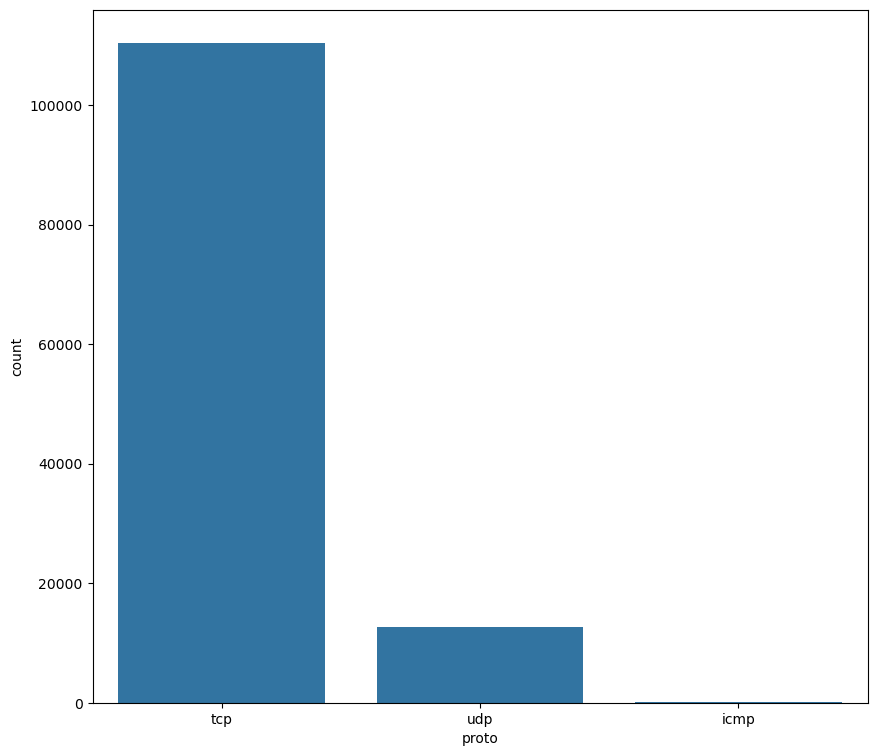

In [63]:
figure = plt.subplots(figsize=(10,9))
sns.countplot(data=iot,x=iot['proto'],order=iot['proto'].value_counts().index)
plt.show()

<Axes: xlabel='Attack_type'>

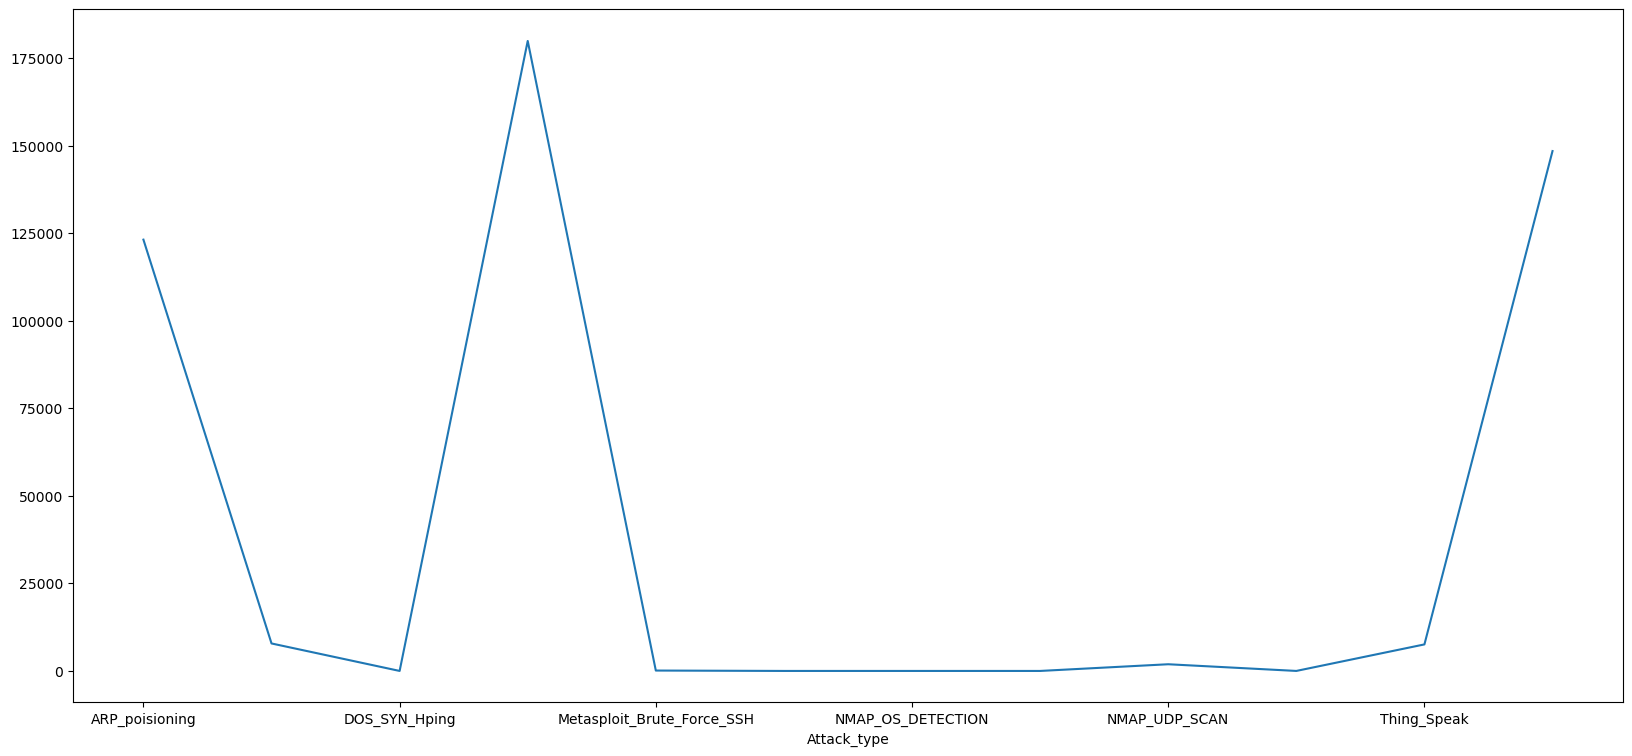

In [82]:
attack_flow_duration = iot.groupby ('Attack_type')['flow_duration'].sum()
attack_flow_duration.plot(figsize=(20, 9))


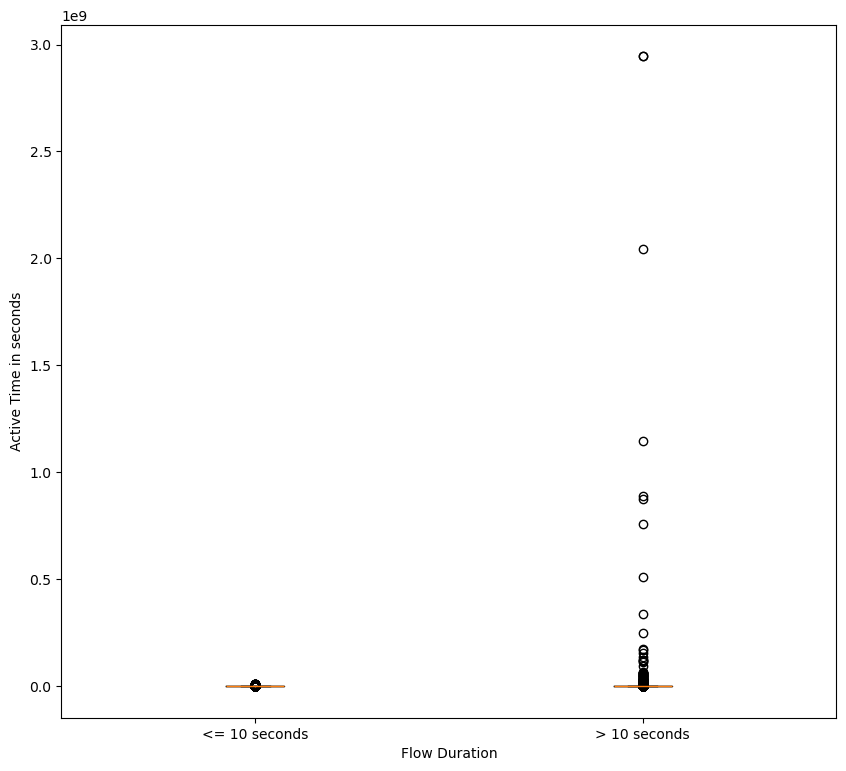

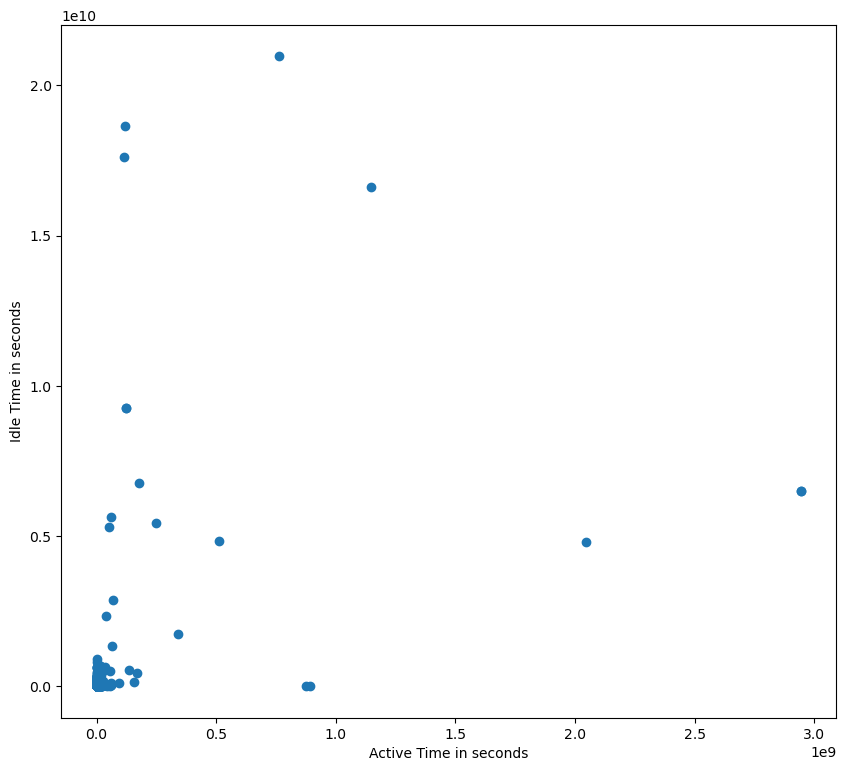

In [78]:
figure = plt.subplots(figsize=(10,9))
plt.boxplot([iot[iot['flow_duration'] <= 10]['active.tot'], iot[iot['flow_duration'] > 10]['active.tot']], labels=['<= 10 seconds', '> 10 seconds'])
plt.xlabel('Flow Duration')
plt.ylabel('Active Time in seconds')
plt.show()
figure = plt.subplots(figsize=(10,9))
plt.scatter(iot['active.tot'], iot['idle.tot'])
plt.xlabel('Active Time in seconds')
plt.ylabel('Idle Time in seconds')
plt.show()